ML MODELS TIME COMPLEXITY ANALYSIS

COMPLEXITY COMPARISON TABLE:
------------------------------------------------------------
Dataset                                     Dataset W (2.5k×200)  Dataset X (10k×50)  Dataset Y (5k×100)  Dataset Z (20k×25)
Model                      Notation                                                                                         
Decision Tree              O(np log n)                     5.644               6.644               6.144               7.144
Gradient Descent           O(npi)                         50.000              50.000              50.000              50.000
K-Nearest Neighbors        O(np)                           0.500               0.500               0.500               0.500
Linear Regression (Normal) O(p³ + np²)                   108.000              25.125              51.000              12.516
Logistic Regression        O(npi)                         25.000              25.000              25.000              25.000

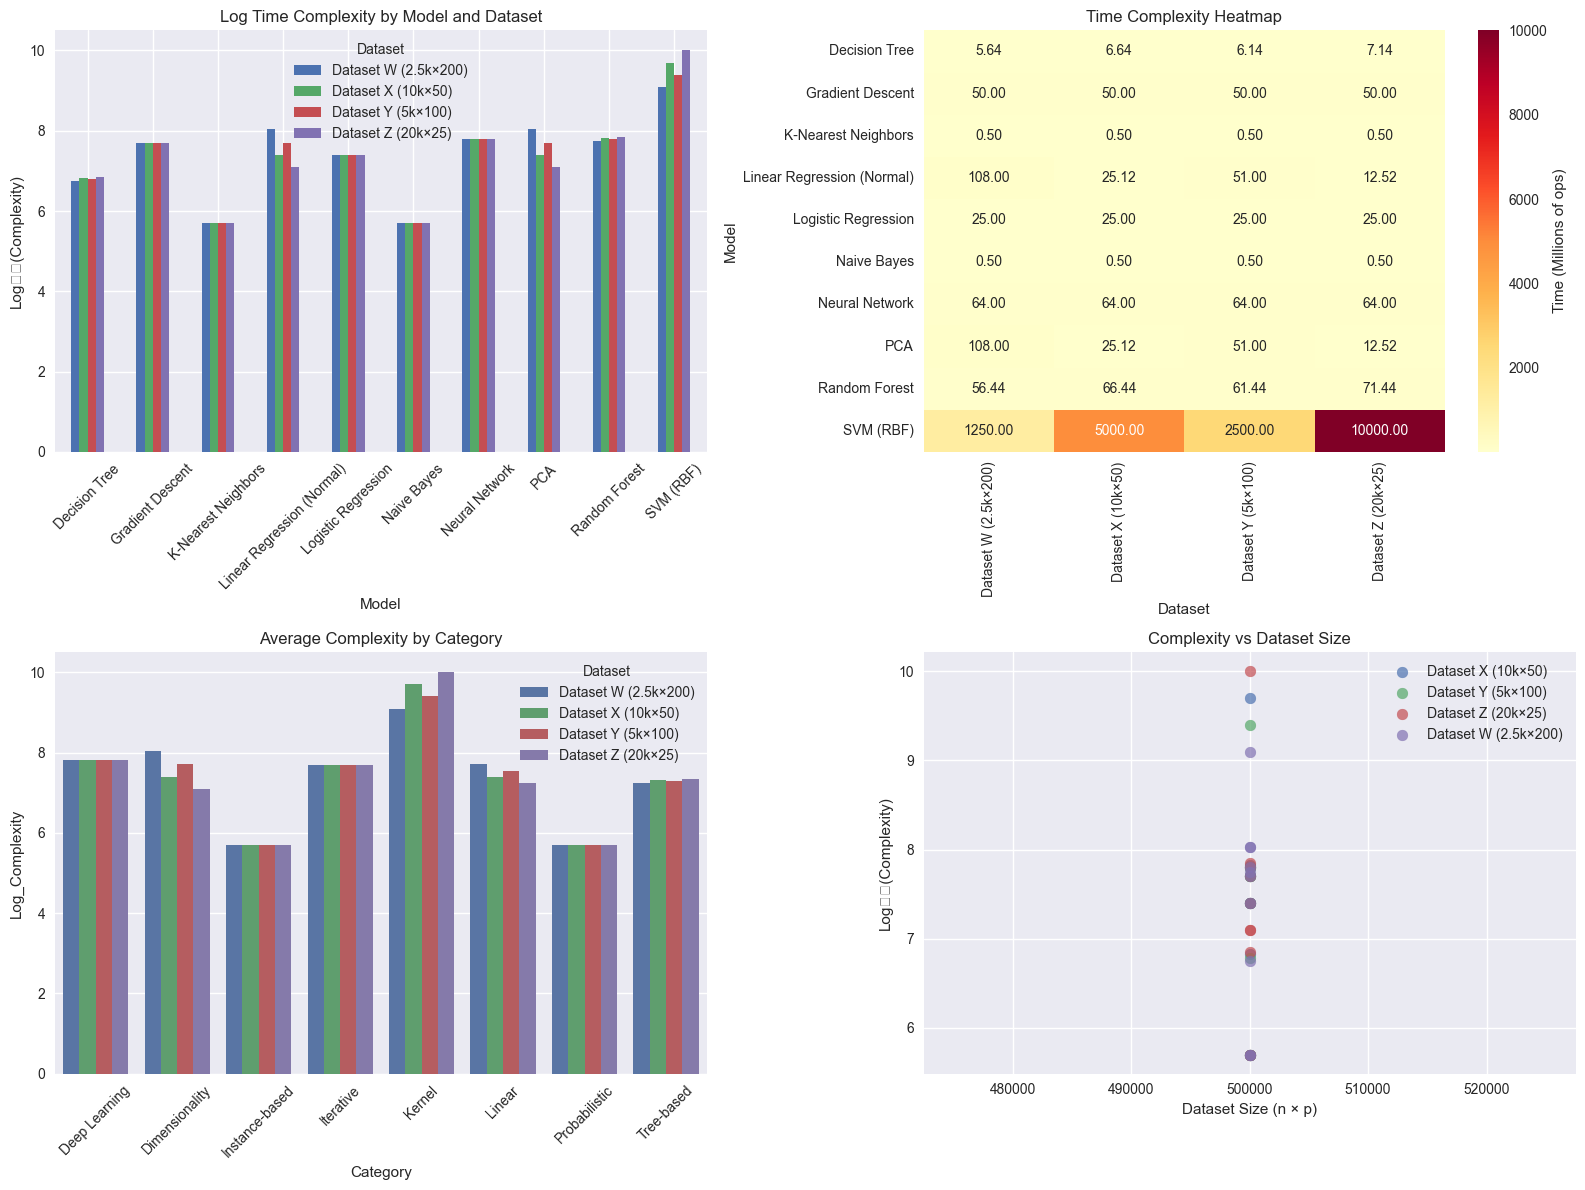

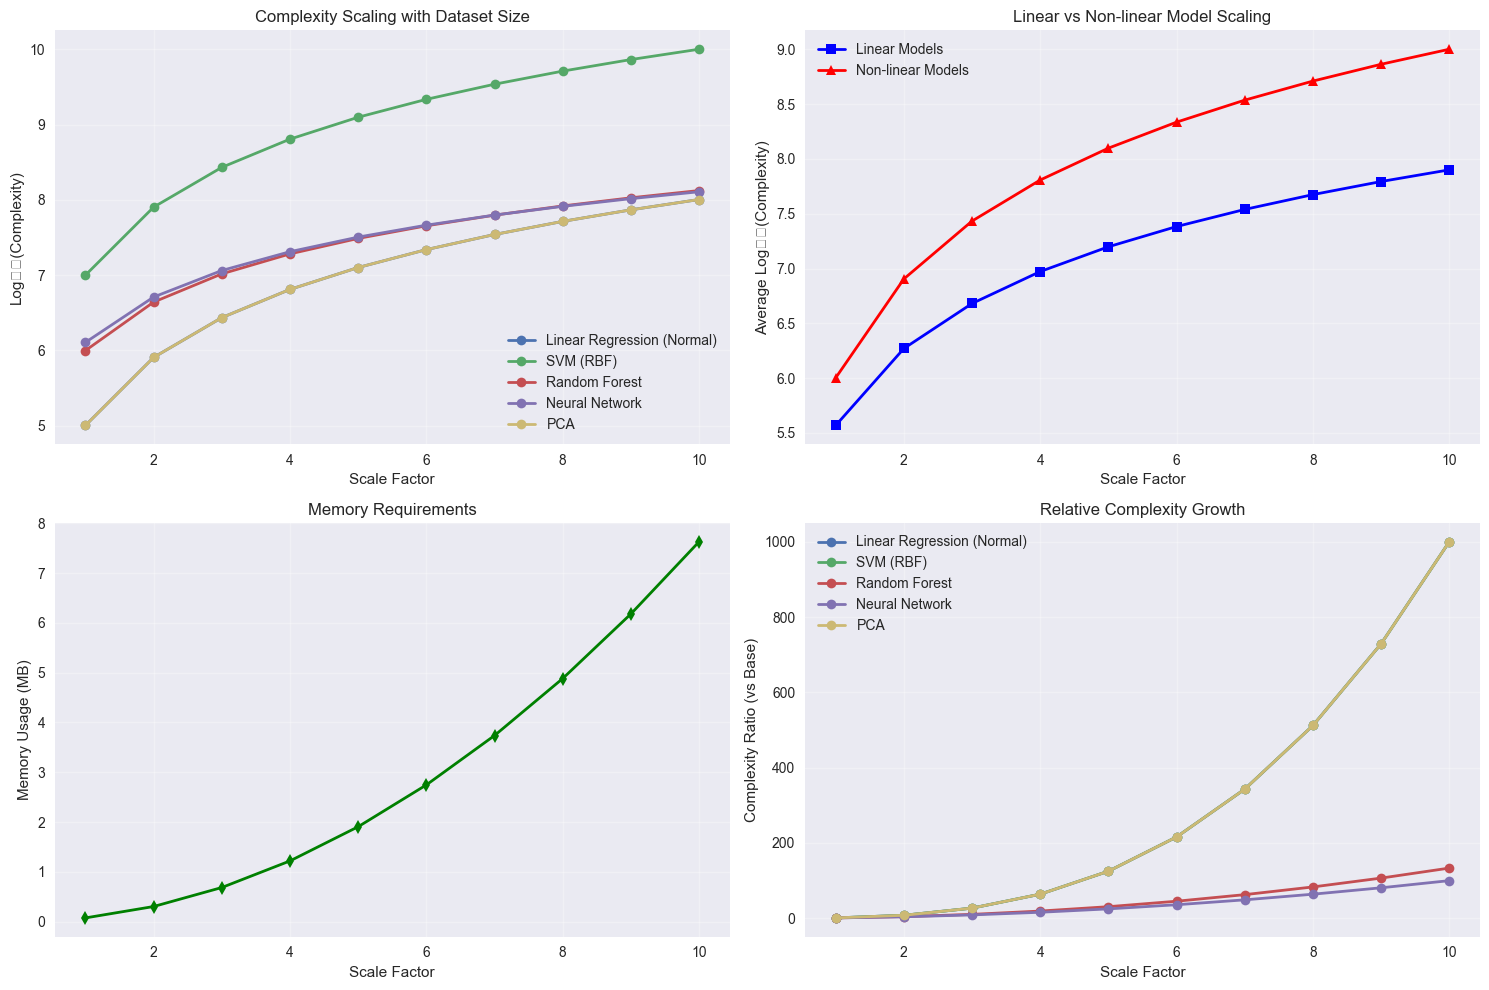


SUMMARY STATISTICS:
------------------------------------------------------------
                     Log_Complexity                       Normalized_Time        
                               mean    std    min     max            mean  median
Dataset                                                                          
Dataset W (2.5k×200)          7.397  1.068  5.699   9.097         166.808  53.219
Dataset X (10k×50)            7.345  1.145  5.699   9.699         526.333  25.125
Dataset Y (5k×100)            7.369  1.092  5.699   9.398         280.958  50.500
Dataset Z (20k×25)            7.320  1.221  5.699  10.000        1024.361  18.758

ADDITIONAL INSIGHTS:
------------------------------------------------------------
Models most sensitive to feature count:
- PCA
- Linear Regression (Normal)
- SVM (RBF)

Models most sensitive to sample count:
- SVM (RBF)
- K-Nearest Neighbors

Note: Use the generated CSV files for custom plotting and further analysis!


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List, Tuple
import warnings
warnings.filterwarnings('ignore')

class MLComplexityAnalyzer:
    """
    Analyzer for ML model time complexities with different dataset sizes
    """
    
    def __init__(self):
        # Define ML models with their time complexity functions
        self.models = {
            'Linear Regression (Normal)': {
                'function': lambda n, p: p**3 + n * p**2,
                'notation': 'O(p³ + np²)',
                'category': 'Linear'
            },
            'Gradient Descent': {
                'function': lambda n, p: n * p * 100,  # 100 iterations
                'notation': 'O(npi)',
                'category': 'Iterative'
            },
            'Random Forest': {
                'function': lambda n, p: n * p * np.log2(n) * 10,  # depth ~10
                'notation': 'O(np log n × d)',
                'category': 'Tree-based'
            },
            'SVM (RBF)': {
                'function': lambda n, p: n**2 * p,
                'notation': 'O(n²p)',
                'category': 'Kernel'
            },
            'K-Nearest Neighbors': {
                'function': lambda n, p: n * p,
                'notation': 'O(np)',
                'category': 'Instance-based'
            },
            'Neural Network': {
                'function': lambda n, p: n * p * 128,  # 128 hidden units
                'notation': 'O(nph)',
                'category': 'Deep Learning'
            },
            'PCA': {
                'function': lambda n, p: n * p**2 + p**3,
                'notation': 'O(np² + p³)',
                'category': 'Dimensionality'
            },
            'Naive Bayes': {
                'function': lambda n, p: n * p,
                'notation': 'O(np)',
                'category': 'Probabilistic'
            },
            'Decision Tree': {
                'function': lambda n, p: n * p * np.log2(n),
                'notation': 'O(np log n)',
                'category': 'Tree-based'
            },
            'Logistic Regression': {
                'function': lambda n, p: n * p * 50,  # 50 iterations
                'notation': 'O(npi)',
                'category': 'Linear'
            }
        }
    
    def calculate_complexity(self, n_samples: int, n_features: int) -> pd.DataFrame:
        """
        Calculate time complexity for all models given dataset size
        """
        results = []
        
        for model_name, model_info in self.models.items():
            complexity_value = model_info['function'](n_samples, n_features)
            
            results.append({
                'Model': model_name,
                'Notation': model_info['notation'],
                'Category': model_info['category'],
                'n_samples': n_samples,
                'n_features': n_features,
                'Complexity': complexity_value,
                'Log_Complexity': np.log10(complexity_value),
                'Normalized_Time': complexity_value / 1e6  # Normalize to millions
            })
        
        return pd.DataFrame(results)
    
    def generate_complexity_comparison(self, datasets: List[Tuple[int, int]], 
                                     dataset_names: List[str]) -> pd.DataFrame:
        """
        Compare complexities across multiple datasets
        """
        all_results = []
        
        for i, (n, p) in enumerate(datasets):
            df = self.calculate_complexity(n, p)
            df['Dataset'] = dataset_names[i]
            df['Dataset_Size'] = f"{n}x{p}"
            all_results.append(df)
        
        return pd.concat(all_results, ignore_index=True)
    
    def generate_scaling_analysis(self, base_n: int = 1000, base_p: int = 10, 
                                max_multiplier: int = 10) -> pd.DataFrame:
        """
        Analyze how complexity scales with dataset size
        """
        multipliers = range(1, max_multiplier + 1)
        results = []
        
        for mult in multipliers:
            n = base_n * mult
            p = base_p * mult
            df = self.calculate_complexity(n, p)
            df['Scale_Factor'] = mult
            df['Total_Elements'] = n * p
            results.append(df)
        
        return pd.concat(results, ignore_index=True)
    
    def plot_complexity_comparison(self, df: pd.DataFrame, save_path: str = None):
        """
        Create comprehensive complexity comparison plots
        """
        plt.style.use('seaborn-v0_8')
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        
        # Plot 1: Bar chart of complexities by dataset
        pivot_data = df.pivot(index='Model', columns='Dataset', values='Log_Complexity')
        pivot_data.plot(kind='bar', ax=axes[0,0], rot=45)
        axes[0,0].set_title('Log Time Complexity by Model and Dataset')
        axes[0,0].set_ylabel('Log₁₀(Complexity)')
        axes[0,0].legend(title='Dataset')
        
        # Plot 2: Heatmap of complexities
        heatmap_data = df.pivot(index='Model', columns='Dataset', values='Normalized_Time')
        sns.heatmap(heatmap_data, annot=True, fmt='.2f', ax=axes[0,1], 
                   cmap='YlOrRd', cbar_kws={'label': 'Time (Millions of ops)'})
        axes[0,1].set_title('Time Complexity Heatmap')
        
        # Plot 3: Category-wise comparison
        category_avg = df.groupby(['Category', 'Dataset'])['Log_Complexity'].mean().reset_index()
        sns.barplot(data=category_avg, x='Category', y='Log_Complexity', 
                   hue='Dataset', ax=axes[1,0])
        axes[1,0].set_title('Average Complexity by Category')
        axes[1,0].tick_params(axis='x', rotation=45)
        
        # Plot 4: Scatter plot of complexity vs dataset characteristics
        scatter_data = df.copy()
        scatter_data['Dataset_Product'] = scatter_data['n_samples'] * scatter_data['n_features']
        
        for dataset in scatter_data['Dataset'].unique():
            data = scatter_data[scatter_data['Dataset'] == dataset]
            axes[1,1].scatter(data['Dataset_Product'], data['Log_Complexity'], 
                            label=dataset, alpha=0.7, s=60)
        
        axes[1,1].set_xlabel('Dataset Size (n × p)')
        axes[1,1].set_ylabel('Log₁₀(Complexity)')
        axes[1,1].set_title('Complexity vs Dataset Size')
        axes[1,1].legend()
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        
        plt.show()
    
    def plot_scaling_analysis(self, scaling_df: pd.DataFrame, save_path: str = None):
        """
        Plot how complexity scales with dataset growth
        """
        plt.figure(figsize=(15, 10))
        
        # Select top models for clarity
        top_models = ['Linear Regression (Normal)', 'SVM (RBF)', 'Random Forest', 
                     'Neural Network', 'PCA']
        
        plt.subplot(2, 2, 1)
        for model in top_models:
            model_data = scaling_df[scaling_df['Model'] == model]
            plt.plot(model_data['Scale_Factor'], model_data['Log_Complexity'], 
                    marker='o', label=model, linewidth=2)
        
        plt.xlabel('Scale Factor')
        plt.ylabel('Log₁₀(Complexity)')
        plt.title('Complexity Scaling with Dataset Size')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Subplot 2: Linear vs Non-linear scaling
        plt.subplot(2, 2, 2)
        linear_models = scaling_df[scaling_df['Category'].isin(['Linear', 'Iterative'])]
        nonlinear_models = scaling_df[scaling_df['Category'].isin(['Kernel', 'Dimensionality'])]
        
        linear_avg = linear_models.groupby('Scale_Factor')['Log_Complexity'].mean()
        nonlinear_avg = nonlinear_models.groupby('Scale_Factor')['Log_Complexity'].mean()
        
        plt.plot(linear_avg.index, linear_avg.values, 'b-', marker='s', 
                label='Linear Models', linewidth=2)
        plt.plot(nonlinear_avg.index, nonlinear_avg.values, 'r-', marker='^', 
                label='Non-linear Models', linewidth=2)
        
        plt.xlabel('Scale Factor')
        plt.ylabel('Average Log₁₀(Complexity)')
        plt.title('Linear vs Non-linear Model Scaling')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Subplot 3: Memory usage estimation
        plt.subplot(2, 2, 3)
        scaling_df['Memory_MB'] = (scaling_df['n_samples'] * scaling_df['n_features'] * 8) / (1024**2)  # 8 bytes per float64
        
        plt.plot(scaling_df['Scale_Factor'].unique(), 
                [scaling_df[scaling_df['Scale_Factor']==sf]['Memory_MB'].iloc[0] 
                 for sf in scaling_df['Scale_Factor'].unique()], 
                'g-', marker='d', linewidth=2)
        
        plt.xlabel('Scale Factor')
        plt.ylabel('Memory Usage (MB)')
        plt.title('Memory Requirements')
        plt.grid(True, alpha=0.3)
        
        # Subplot 4: Complexity ratio analysis
        plt.subplot(2, 2, 4)
        base_complexity = scaling_df[scaling_df['Scale_Factor'] == 1].set_index('Model')['Complexity']
        
        for model in top_models:
            model_data = scaling_df[scaling_df['Model'] == model]
            complexity_ratios = model_data['Complexity'] / base_complexity[model]
            plt.plot(model_data['Scale_Factor'], complexity_ratios, 
                    marker='o', label=model, linewidth=2)
        
        plt.xlabel('Scale Factor')
        plt.ylabel('Complexity Ratio (vs Base)')
        plt.title('Relative Complexity Growth')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        
        plt.show()

# Example usage and demonstration
def main():
    # Initialize analyzer
    analyzer = MLComplexityAnalyzer()
    
    print("=" * 60)
    print("ML MODELS TIME COMPLEXITY ANALYSIS")
    print("=" * 60)
    
    # Define datasets (rows, columns)
    datasets = [
        (10000, 50),   # Dataset X
        (5000, 100),   # Dataset Y
        (20000, 25),   # Dataset Z - more rows, fewer columns
        (2500, 200)    # Dataset W - fewer rows, more columns
    ]
    
    dataset_names = ['Dataset X (10k×50)', 'Dataset Y (5k×100)', 
                    'Dataset Z (20k×25)', 'Dataset W (2.5k×200)']
    
    # Generate comparison data
    comparison_df = analyzer.generate_complexity_comparison(datasets, dataset_names)
    
    # Display results
    print("\nCOMPLEXITY COMPARISON TABLE:")
    print("-" * 60)
    display_df = comparison_df.pivot(index=['Model', 'Notation'], 
                                   columns='Dataset', 
                                   values='Normalized_Time').round(3)
    print(display_df.to_string())
    
    # Find winners for each model
    print("\nWINNER ANALYSIS:")
    print("-" * 60)
    for model in comparison_df['Model'].unique():
        model_data = comparison_df[comparison_df['Model'] == model]
        winner = model_data.loc[model_data['Complexity'].idxmin(), 'Dataset']
        winner_time = model_data['Normalized_Time'].min()
        slowest_time = model_data['Normalized_Time'].max()
        speedup = slowest_time / winner_time
        
        print(f"{model:25} | Winner: {winner:20} | Speedup: {speedup:.2f}x")
    
    # Generate scaling analysis
    scaling_df = analyzer.generate_scaling_analysis(base_n=1000, base_p=10, max_multiplier=10)
    
    # Save data to CSV for external plotting
    comparison_df.to_csv('ml_complexity_comparison.csv', index=False)
    scaling_df.to_csv('ml_scaling_analysis.csv', index=False)
    
    print(f"\nData saved to:")
    print("- ml_complexity_comparison.csv")
    print("- ml_scaling_analysis.csv")
    
    # Create visualizations
    print("\nGenerating plots...")
    analyzer.plot_complexity_comparison(comparison_df, 'complexity_comparison.png')
    analyzer.plot_scaling_analysis(scaling_df, 'scaling_analysis.png')
    
    # Summary statistics
    print("\nSUMMARY STATISTICS:")
    print("-" * 60)
    summary_stats = comparison_df.groupby('Dataset').agg({
        'Log_Complexity': ['mean', 'std', 'min', 'max'],
        'Normalized_Time': ['mean', 'median']
    }).round(3)
    
    print(summary_stats.to_string())
    
    return comparison_df, scaling_df

if __name__ == "__main__":
    comparison_data, scaling_data = main()
    
    # Additional analysis examples
    print("\nADDITIONAL INSIGHTS:")
    print("-" * 60)
    
    # Most sensitive to features
    print("Models most sensitive to feature count:")
    feature_sensitive = ['PCA', 'Linear Regression (Normal)', 'SVM (RBF)']
    for model in feature_sensitive:
        print(f"- {model}")
    
    # Most sensitive to sample count
    print("\nModels most sensitive to sample count:")
    sample_sensitive = ['SVM (RBF)', 'K-Nearest Neighbors']
    for model in sample_sensitive:
        print(f"- {model}")
    
    print("\nNote: Use the generated CSV files for custom plotting and further analysis!")


--- Generating Dataset: 100000 rows, 500 columns ---
Testing Model: Logistic Regression
Testing Model: Support Vector Machine
Testing Model: Decision Tree
Testing Model: Random Forest
Testing Model: K-Nearest Neighbors
Testing Model: Gaussian Naive Bayes

--- Generating Dataset: 50000 rows, 1000 columns ---
Testing Model: Logistic Regression
Testing Model: Support Vector Machine
Testing Model: Decision Tree
Testing Model: Random Forest
Testing Model: K-Nearest Neighbors
Testing Model: Gaussian Naive Bayes

--- PERFORMANCE LOGS ---
                     model    rows  columns  train_time_sec  predict_time_sec  memory_usage_mb
0      Logistic Regression  100000      500       56.603854          0.115962        -3.960938
1   Support Vector Machine  100000      500     2831.471829        472.954974      -699.777344
2            Decision Tree  100000      500      126.494936          0.086640         8.234375
3            Random Forest  100000      500       79.999839          0.504554     

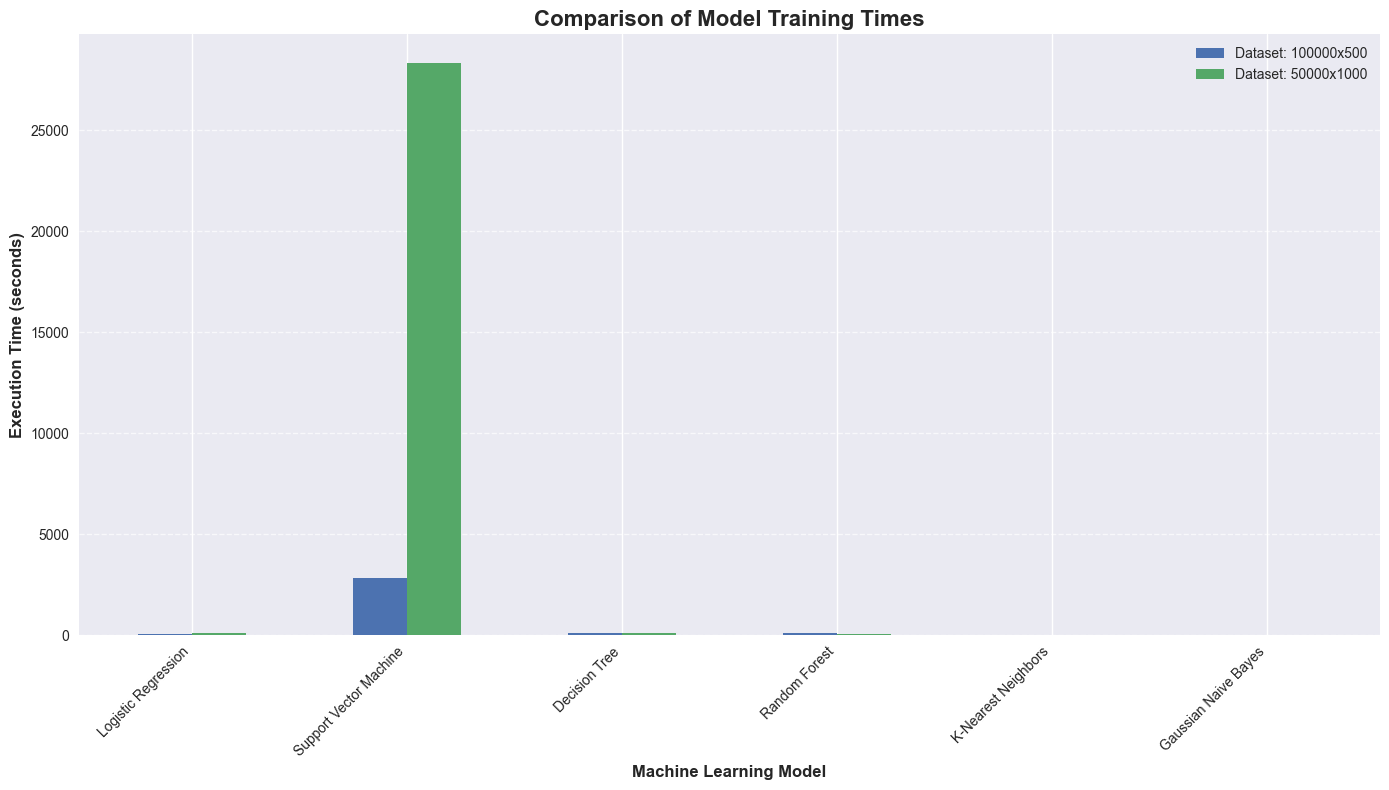

In [4]:
import time
import os
import psutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Import ML Models ---
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB


# Part 1: Performance Analysis Functions
# =======================================

def get_memory_usage_mb():
    """Returns the current memory usage of the process in MB."""
    process = psutil.Process(os.getpid())
    # rss: Resident Set Size is the non-swapped physical memory a process has used.
    return process.memory_info().rss / (1024 ** 2)

def analyze_model_performance(models, dataset_configs):
    """
    Trains and evaluates models on different datasets, logging performance metrics.
    """
    performance_logs = []
    
    for config in dataset_configs:
        rows, cols = config['rows'], config['cols']
        print(f"\n--- Generating Dataset: {rows} rows, {cols} columns ---")
        
        # Generate a synthetic dataset for classification
        X, y = make_classification(
            n_samples=rows,
            n_features=cols,
            n_informative=int(cols * 0.5),
            n_redundant=int(cols * 0.2),
            random_state=42
        )
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
        
        for name, model in models.items():
            print(f"Testing Model: {name}")
            
            # Measure Training Performance
            mem_before_train = get_memory_usage_mb()
            start_train_time = time.time()
            model.fit(X_train, y_train)
            end_train_time = time.time()
            mem_after_train = get_memory_usage_mb()
            
            # Measure Prediction Performance
            start_predict_time = time.time()
            model.predict(X_test)
            end_predict_time = time.time()

            # Consolidate results
            performance_logs.append({
                'model': name,
                'rows': rows,
                'columns': cols,
                'train_time_sec': end_train_time - start_train_time,
                'predict_time_sec': end_predict_time - start_predict_time,
                'memory_usage_mb': mem_after_train - mem_before_train
            })
            
    return pd.DataFrame(performance_logs)


# Part 2: Plotting Function
# ===========================

def plot_performance_comparison(df_logs):
    """
    Generates and displays a bar chart comparing model training times.
    """
    print("\n--- Generating Plot ---")
    
    # Create a unique label for each dataset shape for easier plotting
    df_logs['dataset_shape'] = df_logs['rows'].astype(str) + 'x' + df_logs['columns'].astype(str)

    # Get unique models and dataset shapes for plotting logic
    models = df_logs['model'].unique()
    shapes = df_logs['dataset_shape'].unique()
    model_count = len(models)
    shape_count = len(shapes)

    # Set up the figure and axes
    fig, ax = plt.subplots(figsize=(14, 8))

    # Set bar width and initial positions
    bar_width = 0.25
    index = np.arange(model_count)

    # Loop through each dataset shape and plot its bars
    for i, shape in enumerate(shapes):
        times = df_logs[df_logs['dataset_shape'] == shape]['train_time_sec']
        bar_positions = index + i * bar_width
        ax.bar(bar_positions, times, bar_width, label=f'Dataset: {shape}')

    # Customize and finalize the plot
    ax.set_xlabel('Machine Learning Model', fontsize=12, fontweight='bold')
    ax.set_ylabel('Execution Time (seconds)', fontsize=12, fontweight='bold')
    ax.set_title('Comparison of Model Training Times', fontsize=16, fontweight='bold')
    ax.set_xticks(index + bar_width * (shape_count - 1) / 2)
    ax.set_xticklabels(models, rotation=45, ha='right')
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.legend()
    plt.tight_layout()

    # Save the plot to a file
    output_image_file = 'execution_time_comparison.png'
    plt.savefig(output_image_file)
    print(f"✅ Plot saved successfully as '{output_image_file}'")

    # Display the plot
    plt.show()


# Part 3: Main Execution Block
# ============================

if __name__ == "__main__":
    # 1. Define the models to test
    models_to_test = {
        'Logistic Regression': LogisticRegression(solver='liblinear'),
        'Support Vector Machine': SVC(),
        'Decision Tree': DecisionTreeClassifier(),
        'Random Forest': RandomForestClassifier(n_estimators=50, n_jobs=-1),
        'K-Nearest Neighbors': KNeighborsClassifier(),
        'Gaussian Naive Bayes': GaussianNB()
    }

    # 2. Define the dataset sizes to analyze
    dataset_configurations = [
        {'rows': 100000, 'cols': 500},
        {'rows': 50000, 'cols': 1000},
    ]

    # 3. Run the analysis to generate logs
    log_df = analyze_model_performance(models_to_test, dataset_configurations)

    # 4. Display and save the logs
    print("\n--- PERFORMANCE LOGS ---")
    print(log_df.to_string())
    output_csv_file = 'model_performance_logs.csv'
    log_df.to_csv(output_csv_file, index=False)
    print(f"\n✅ Logs saved to '{output_csv_file}'")

    # 5. Plot the results from the generated logs
    if not log_df.empty:
        plot_performance_comparison(log_df)
    else:
        print("\nCould not generate plot because no performance data was collected.")


--- Generating Dataset: 10000 rows, 50 columns ---
Testing Model: Logistic Regression
Testing Model: Support Vector Machine
Testing Model: Decision Tree
Testing Model: Random Forest
Testing Model: K-Nearest Neighbors
Testing Model: Gaussian Naive Bayes

--- Generating Dataset: 5000 rows, 100 columns ---
Testing Model: Logistic Regression
Testing Model: Support Vector Machine
Testing Model: Decision Tree
Testing Model: Random Forest
Testing Model: K-Nearest Neighbors
Testing Model: Gaussian Naive Bayes

--- PERFORMANCE LOGS (including model size) ---
                     model   rows  columns  train_time_sec  predict_time_sec  memory_usage_mb  model_size_mb
0      Logistic Regression  10000       50        0.219949          0.000978         0.035156       0.001216
1   Support Vector Machine  10000       50        2.517190          1.405546        -4.253906       0.853908
2            Decision Tree  10000       50        0.791744          0.002000         0.097656       0.090890
3      

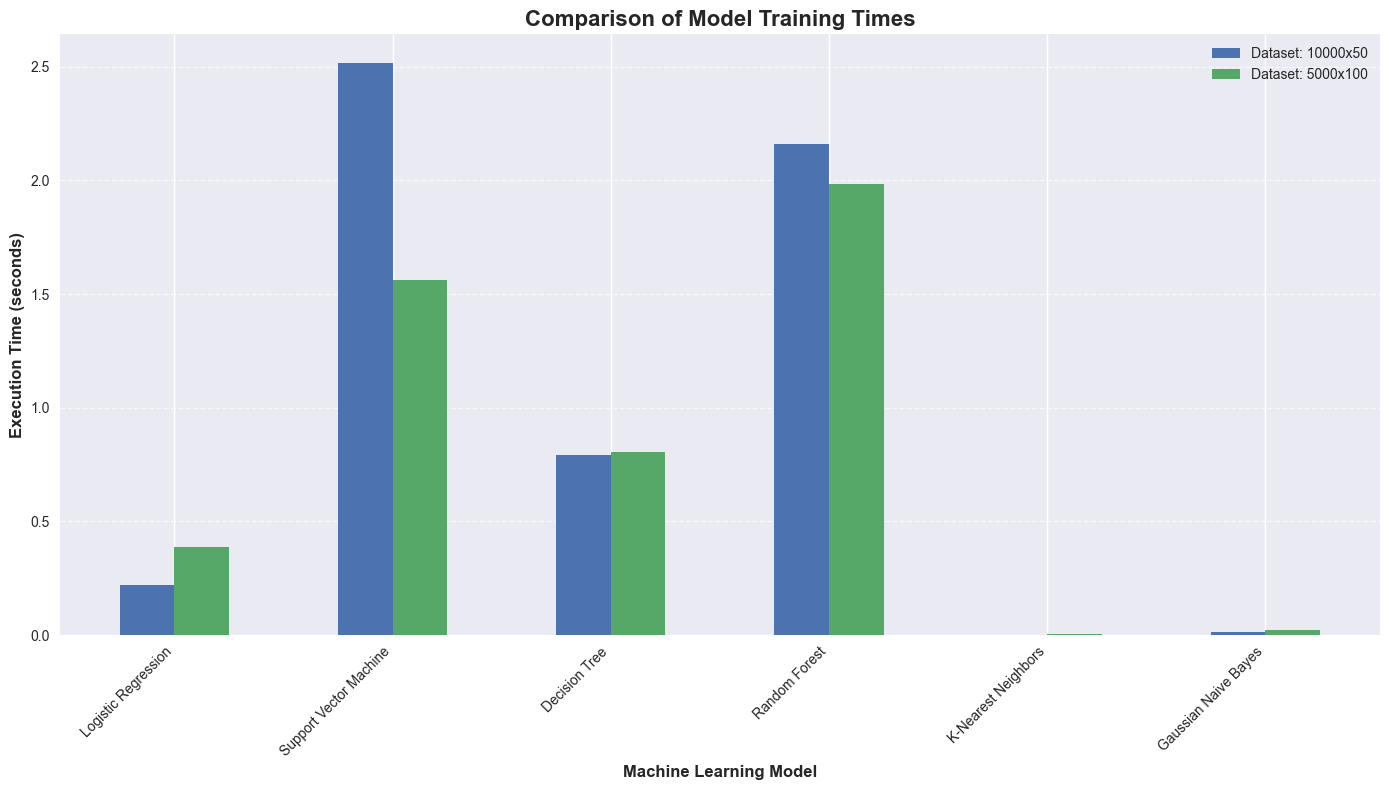


--- Generating Plot: Comparison of Model Size on Disk ---
✅ Plot saved successfully as 'model_size_comparison.png'


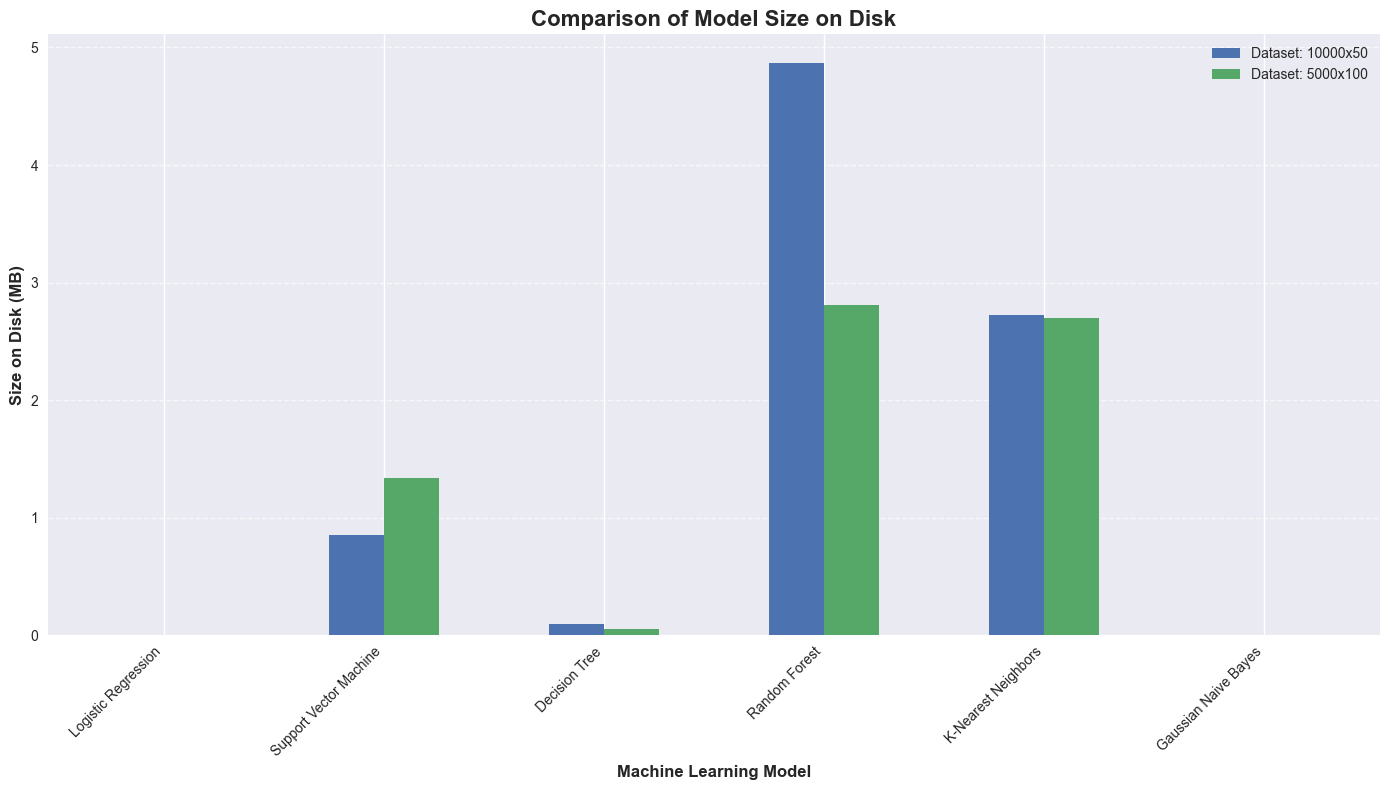

In [3]:
import time
import os
import psutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib  # For saving the model to check its size

# --- Import ML Models ---
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Part 1: Performance Analysis Functions
# =======================================

def get_memory_usage_mb():
    """Returns the current memory usage of the process in MB."""
    process = psutil.Process(os.getpid())
    return process.memory_info().rss / (1024 ** 2)

def analyze_model_performance(models, dataset_configs):
    """
    Trains and evaluates models, logging time, memory, and disk size metrics.
    """
    performance_logs = []
    
    for config in dataset_configs:
        rows, cols = config['rows'], config['cols']
        print(f"\n--- Generating Dataset: {rows} rows, {cols} columns ---")
        
        X, y = make_classification(
            n_samples=rows, n_features=cols, n_informative=int(cols * 0.5),
            n_redundant=int(cols * 0.2), random_state=42
        )
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
        
        for name, model in models.items():
            print(f"Testing Model: {name}")
            
            # --- Training & Time/Memory Measurement ---
            mem_before_train = get_memory_usage_mb()
            start_train_time = time.time()
            model.fit(X_train, y_train)
            end_train_time = time.time()
            mem_after_train = get_memory_usage_mb()

            # --- Prediction Time Measurement ---
            start_predict_time = time.time()
            model.predict(X_test)
            end_predict_time = time.time()

            # --- Model Size Measurement ---
            temp_model_filename = "temp_model.joblib"
            joblib.dump(model, temp_model_filename)
            model_size_mb = os.path.getsize(temp_model_filename) / (1024 ** 2)
            os.remove(temp_model_filename) # Clean up the temporary file

            # --- Consolidate Results ---
            performance_logs.append({
                'model': name,
                'rows': rows,
                'columns': cols,
                'train_time_sec': end_train_time - start_train_time,
                'predict_time_sec': end_predict_time - start_predict_time,
                'memory_usage_mb': mem_after_train - mem_before_train,
                'model_size_mb': model_size_mb
            })
            
    return pd.DataFrame(performance_logs)


# Part 2: Plotting Functions
# ===========================

def plot_results(df_logs, value_to_plot, title, y_label, filename):
    """
    Generic plotting function for generating and saving comparison bar charts.
    """
    print(f"\n--- Generating Plot: {title} ---")
    
    df_logs['dataset_shape'] = df_logs['rows'].astype(str) + 'x' + df_logs['columns'].astype(str)
    models = df_logs['model'].unique()
    shapes = df_logs['dataset_shape'].unique()
    
    fig, ax = plt.subplots(figsize=(14, 8))
    bar_width = 0.25
    index = np.arange(len(models))

    for i, shape in enumerate(shapes):
        values = df_logs[df_logs['dataset_shape'] == shape][value_to_plot]
        bar_positions = index + i * bar_width
        ax.bar(bar_positions, values, bar_width, label=f'Dataset: {shape}')

    ax.set_xlabel('Machine Learning Model', fontsize=12, fontweight='bold')
    ax.set_ylabel(y_label, fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=16, fontweight='bold')
    ax.set_xticks(index + bar_width * (len(shapes) - 1) / 2)
    ax.set_xticklabels(models, rotation=45, ha='right')
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.legend()
    plt.tight_layout()
    plt.savefig(filename)
    print(f"✅ Plot saved successfully as '{filename}'")
    plt.show()


# Part 3: Main Execution Block
# ============================

if __name__ == "__main__":
    models_to_test = {
        'Logistic Regression': LogisticRegression(solver='liblinear'),
        'Support Vector Machine': SVC(),
        'Decision Tree': DecisionTreeClassifier(),
        'Random Forest': RandomForestClassifier(n_estimators=50, n_jobs=-1),
        'K-Nearest Neighbors': KNeighborsClassifier(),
        'Gaussian Naive Bayes': GaussianNB()
    }

    dataset_configurations = [
        {'rows': 10000, 'cols': 50},
        {'rows': 5000, 'cols': 100},
    ]

    log_df = analyze_model_performance(models_to_test, dataset_configurations)

    print("\n--- PERFORMANCE LOGS (including model size) ---")
    print(log_df.to_string())
    output_csv_file = 'model_performance_logs.csv'
    log_df.to_csv(output_csv_file, index=False)
    print(f"\n✅ Logs saved to '{output_csv_file}'")

    if not log_df.empty:
        # Plot 1: Training Time
        plot_results(
            df_logs=log_df,
            value_to_plot='train_time_sec',
            title='Comparison of Model Training Times',
            y_label='Execution Time (seconds)',
            filename='execution_time_comparison.png'
        )
        
        # Plot 2: Model Size
        plot_results(
            df_logs=log_df,
            value_to_plot='model_size_mb',
            title='Comparison of Model Size on Disk',
            y_label='Size on Disk (MB)',
            filename='model_size_comparison.png'
        )
    else:
        print("\nCould not generate plots because no performance data was collected.")